# Exploration approfondie de la base d'apprentissage

In [22]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
base = pd.read_csv("../data_finale/base_apprentissage.csv")

In [24]:
target = "market_value_in_eur"
numeric_candidates = [
    "age_numeric", "xg_buildup", "Performance_Gls", "Performance_Ast",
    "Playing Time_Min", "injury_days_total", "Performance_GA90",
    "Per 90 Minutes_Gls", "Per 90 Minutes_Ast", "Performance_G+A"
]
categorical_candidates = ["pos", "league", "nation", "team", "season", "season_year"]

numeric_columns = [c for c in base.select_dtypes(include=[np.number]).columns if c != target]
selected_numeric = [c for c in numeric_candidates if c in base.columns]
categorical_columns = [c for c in categorical_candidates if c in base.columns]

In [25]:
print("Comprendre le dataset")
print("Shape :", base.shape)
print("\nTypes des variables :")
print(base.dtypes)
print("\nStatistiques descriptives :")
display(base.describe(include="all").T)

Comprendre le dataset
Shape : (17122, 129)

Types des variables :
league                      str
season                    int64
team                        str
player                      str
nation                      str
                         ...   
injury_mollet_tibia     float64
injury_dos_bassin       float64
injury_trauma_severe    float64
injury_medical_repos    float64
injury_minor_unknown    float64
Length: 129, dtype: object

Statistiques descriptives :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
league,17122,5,ESP-La Liga,3689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,17122.0,NaN,NaN,NaN,2262.805397,168.446901,2021.0,2122.0,2223.0,2425.0,2526.0
team,17122,137,Sevilla,223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player,17122,5511,Marquinhos,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nation,17118,129,ESP,2592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
injury_mollet_tibia,17122.0,NaN,NaN,NaN,0.048242,0.214283,0.0,0.0,0.0,0.0,1.0
injury_dos_bassin,17122.0,NaN,NaN,NaN,0.013667,0.116106,0.0,0.0,0.0,0.0,1.0
injury_trauma_severe,17122.0,NaN,NaN,NaN,0.036269,0.186964,0.0,0.0,0.0,0.0,1.0
injury_medical_repos,17122.0,NaN,NaN,NaN,0.074407,0.26244,0.0,0.0,0.0,0.0,1.0


In [26]:
print("\nVérifier les valeurs manquantes")
missing = base.isna().sum().sort_values(ascending=False)
missing_pct = 100 * missing / len(base)
missing_summary = pd.concat([missing, missing_pct], axis=1, keys=["missing", "pct"])
display(missing_summary[missing_summary["missing"] > 0])

print("\nVérifier les doublons")
print("Doublons totaux :", base.duplicated().sum())


Vérifier les valeurs manquantes


,missing,pct
Performance_PKcon,17122,100.000000
Performance_PKwon,17122,100.000000
Penalty Kicks_Save%,16231,94.796169
Performance_CS%,15918,92.968111
Performance_Save%,15887,92.787058
Performance_GA90,15863,92.646887
Performance_W,15863,92.646887
Performance_D,15863,92.646887
Performance_Saves,15863,92.646887
Performance_CS,15863,92.646887



Vérifier les doublons
Doublons totaux : 0



Analyser la variable cible (Valeur Marchande)


count    1.493200e+04
mean     1.205389e+07
std      1.710134e+07
min      5.000000e+04
25%      2.200000e+06
50%      6.000000e+06
75%      1.500000e+07
max      2.000000e+08
Name: market_value_in_eur, dtype: float64

Skewness : 3.5362577163969084
Kurtosis : 19.679793182460802

Analyse des distributions des variables numériques sélectionnées


,xg_buildup,Performance_Gls,Performance_Ast,Playing Time_Min,injury_days_total,Performance_GA90,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Performance_G+A
count,8689.000000,17122.000000,17122.00000,17122.000000,17122.000000,1259.000000,17122.000000,17122.000000,17122.000000
mean,3.458029,1.739575,1.22036,1261.434237,32.193844,1.607681,0.114345,0.085385,2.959935
std,3.598892,3.188652,1.95519,960.693360,58.428034,2.801920,0.238018,0.286400,4.561596
min,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.696678,0.000000,0.00000,360.000000,0.000000,1.060000,0.000000,0.000000,0.000000
50%,2.439951,0.000000,0.00000,1146.000000,7.000000,1.410000,0.000000,0.000000,1.000000
75%,5.028797,2.000000,2.00000,2041.000000,42.000000,1.800000,0.160000,0.120000,4.000000
max,27.680503,41.000000,19.00000,3420.000000,1280.000000,90.000000,9.000000,18.000000,48.000000



Analyse des variables catégorielles

Top 10 valeurs pour pos :


pos
MF       5266
DF       4336
FW       2194
MF,FW    1298
GK       1258
FW,MF    1086
DF,MF     987
MF,DF     676
DF,FW      19
FW,DF       2
Name: count, dtype: int64

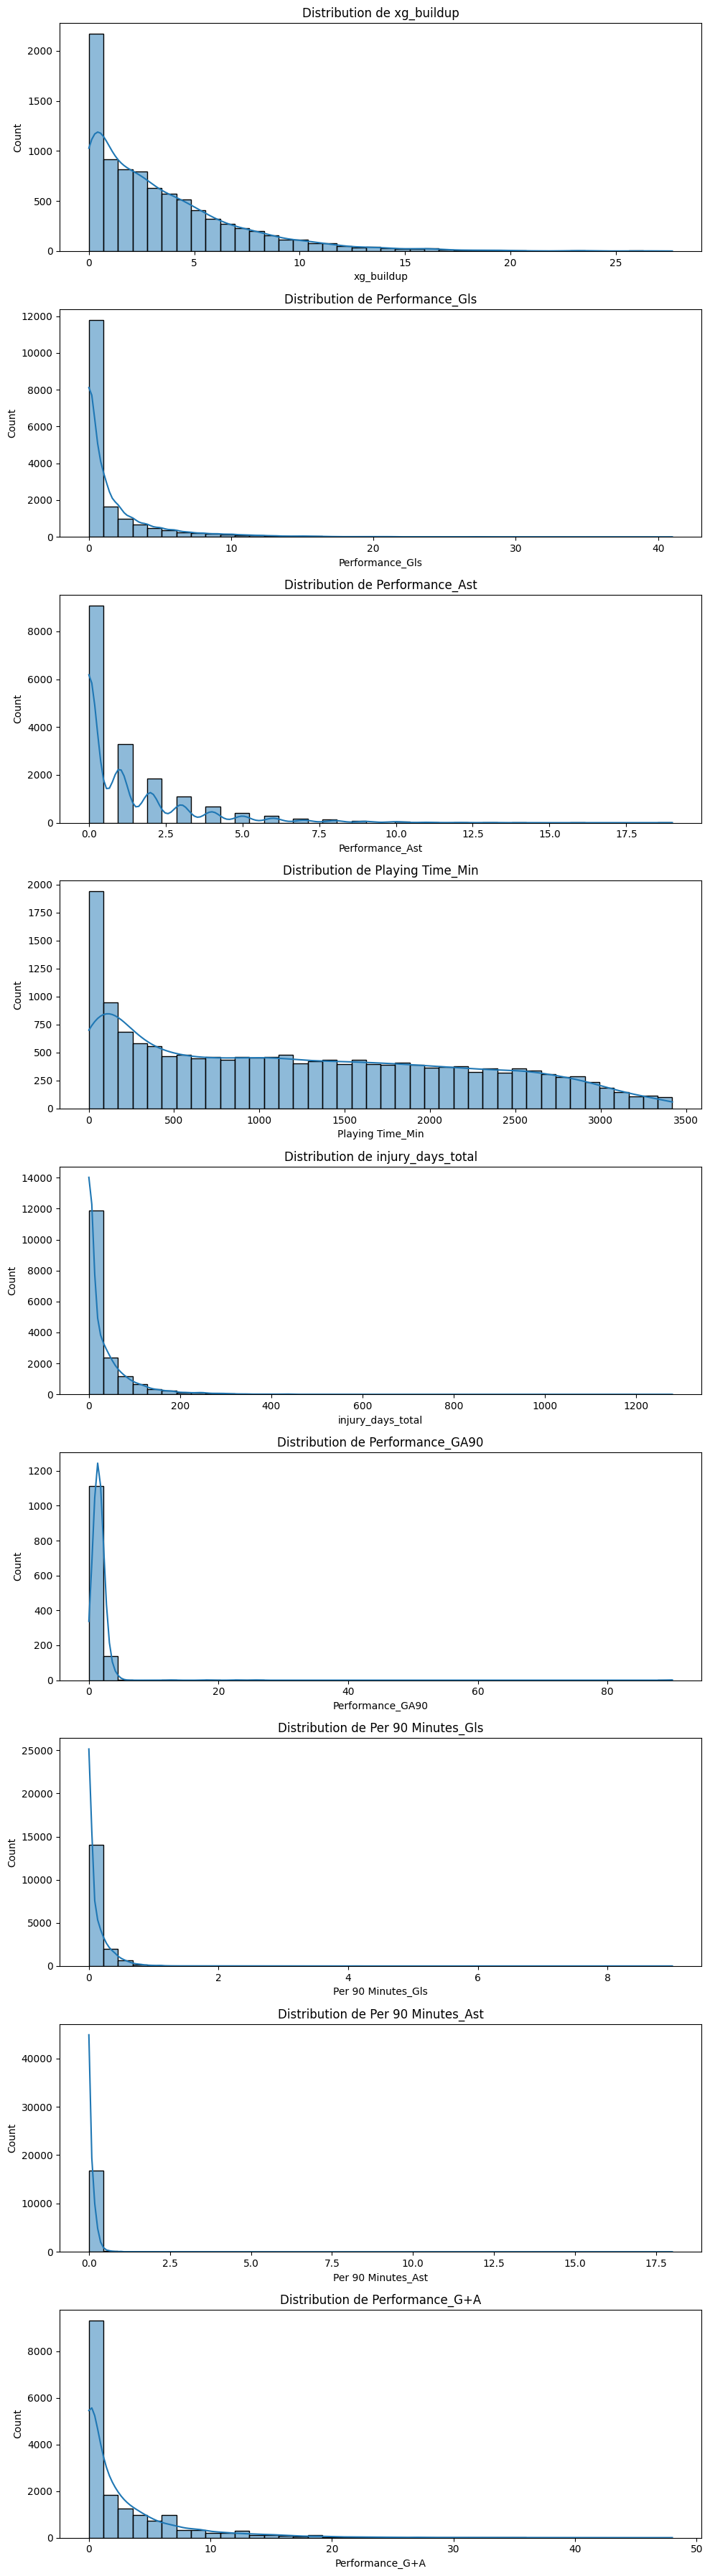

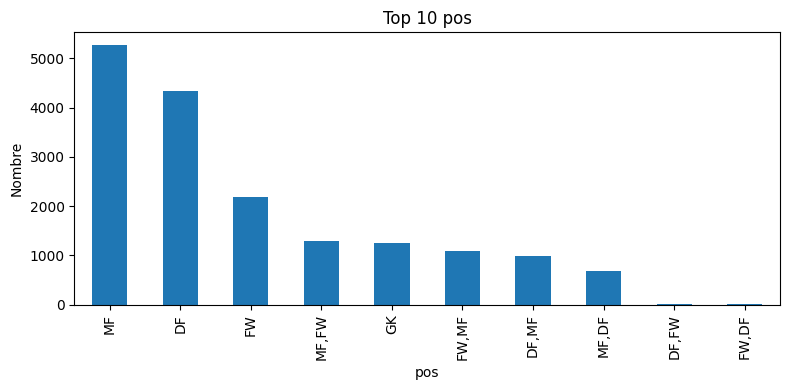


Top 10 valeurs pour league :


league
ESP-La Liga           3689
ITA-Serie A           3664
ENG-Premier League    3461
FRA-Ligue 1           3347
GER-Bundesliga        2961
Name: count, dtype: int64

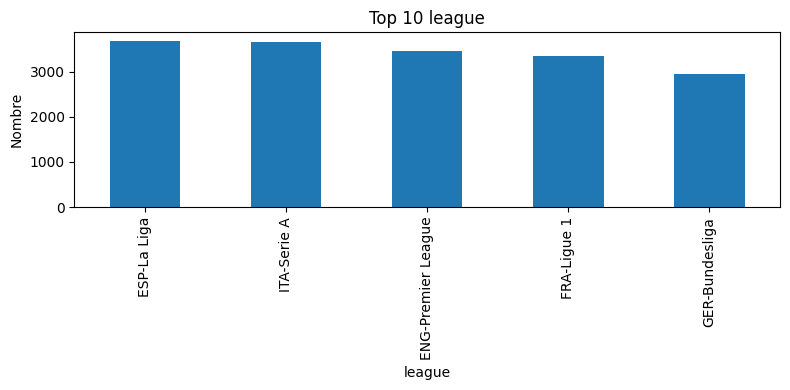


Top 10 valeurs pour nation :


nation
ESP    2592
FRA    1904
ITA    1405
GER    1357
ENG    1172
BRA     972
ARG     472
POR     409
NED     400
BEL     290
Name: count, dtype: int64

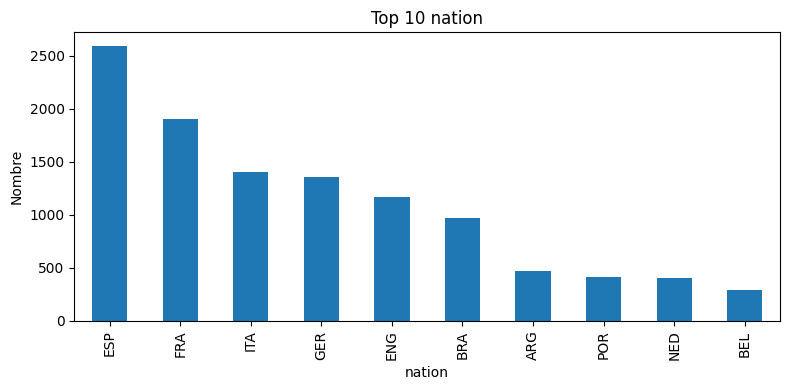


Top 10 valeurs pour team :


team
Sevilla                223
Real Betis             215
Paris Saint-Germain    212
Fiorentina             200
Leverkusen             197
Juventus               197
Lyon                   194
Hellas Verona          194
Real Madrid            189
Real Sociedad          189
Name: count, dtype: int64

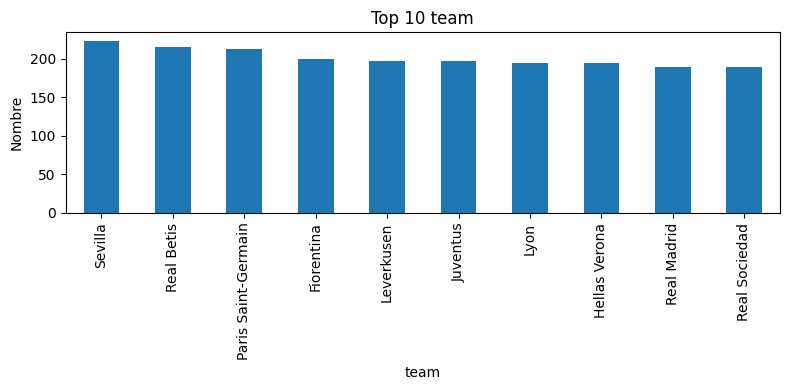


Top 10 valeurs pour season :


season
2122    3033
2223    2991
2021    2956
2425    2921
2324    2906
2526    2315
Name: count, dtype: int64

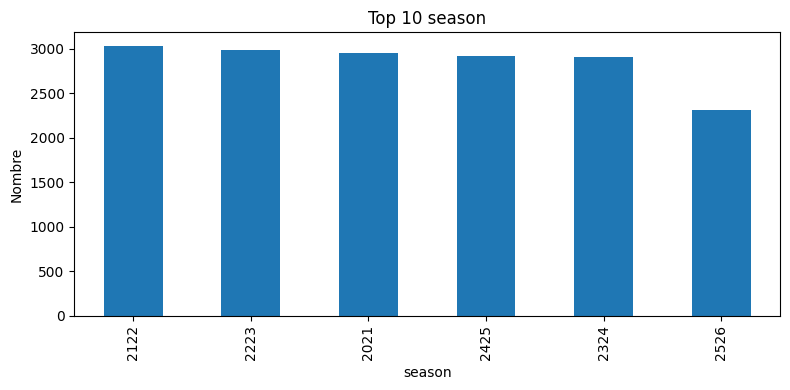


Top 10 valeurs pour season_year :


season_year
2021    3033
2022    2991
2020    2956
2024    2921
2023    2906
2025    2315
Name: count, dtype: int64

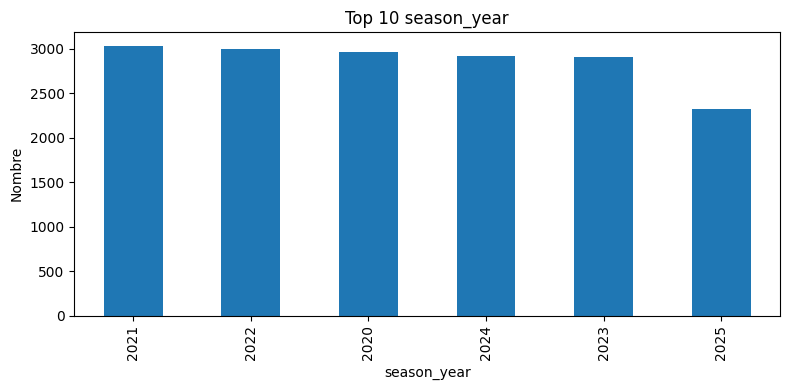

In [27]:
print("\nAnalyser la variable cible (Valeur Marchande)")
if target in base.columns:
    display(base[target].describe())
    print("Skewness :", base[target].skew())
    print("Kurtosis :", base[target].kurtosis())
else:
    print(f"Variable cible {target} introuvable dans le DataFrame")

if selected_numeric:
    print("\nAnalyse des distributions des variables numériques sélectionnées")
    display(base[selected_numeric].describe())

    fig, axs = plt.subplots(len(selected_numeric), 1, figsize=(10, 4 * len(selected_numeric)))
    if len(selected_numeric) == 1:
        axs = [axs]
    for ax, col in zip(axs, selected_numeric):
        sns.histplot(base[col].dropna(), kde=True, ax=ax, bins=40)
        ax.set_title(f"Distribution de {col}")
        ax.set_xlabel(col)
    plt.tight_layout()
else:
    print("\nAucune variable numérique sélectionnée n'a été trouvée dans le DataFrame.")

if categorical_columns:
    print("\nAnalyse des variables catégorielles")
    for col in categorical_columns:
        print(f"\nTop 10 valeurs pour {col} :")
        display(base[col].value_counts(dropna=False).head(10))
        plt.figure(figsize=(8, 4))
        base[col].value_counts(dropna=False).head(10).plot(kind="bar")
        plt.title(f"Top 10 {col}")
        plt.ylabel("Nombre")
        plt.tight_layout()
        plt.show()
else:
    print("\nAucune variable catégorielle ciblée n'a été trouvée dans le dataframe.")

In [28]:
print("\nDétecter les outliers numériques")
numeric_data = base.select_dtypes(include=[np.number])
q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_counts = ((numeric_data < lower) | (numeric_data > upper)).sum().sort_values(ascending=False)
display(outlier_counts[outlier_counts > 0])


Détecter les outliers numériques


injury_musculaire            3682
injury_musculaire_count      3682
injury_musculaire_nb_d       3682
injury_musculaire_nb_m       3541
injury_minor_unknown_nb_d    2878
                             ... 
Performance_W                  10
Penalty Kicks_PKatt             5
Penalty Kicks_PKA               4
Performance_L                   2
Standard_G/SoT                  1
Length: 98, dtype: int64


Étudier les relations entre variables et VM


Performance_W        0.624231
xg_chain             0.618251
Performance_CS       0.567894
Team Success_onG     0.516945
xg_buildup           0.513561
                       ...   
Subs_Subs           -0.082816
Performance_GA90    -0.177763
Subs_unSub          -0.272890
Performance_PKwon         NaN
Performance_PKcon         NaN
Name: market_value_in_eur, Length: 115, dtype: float64

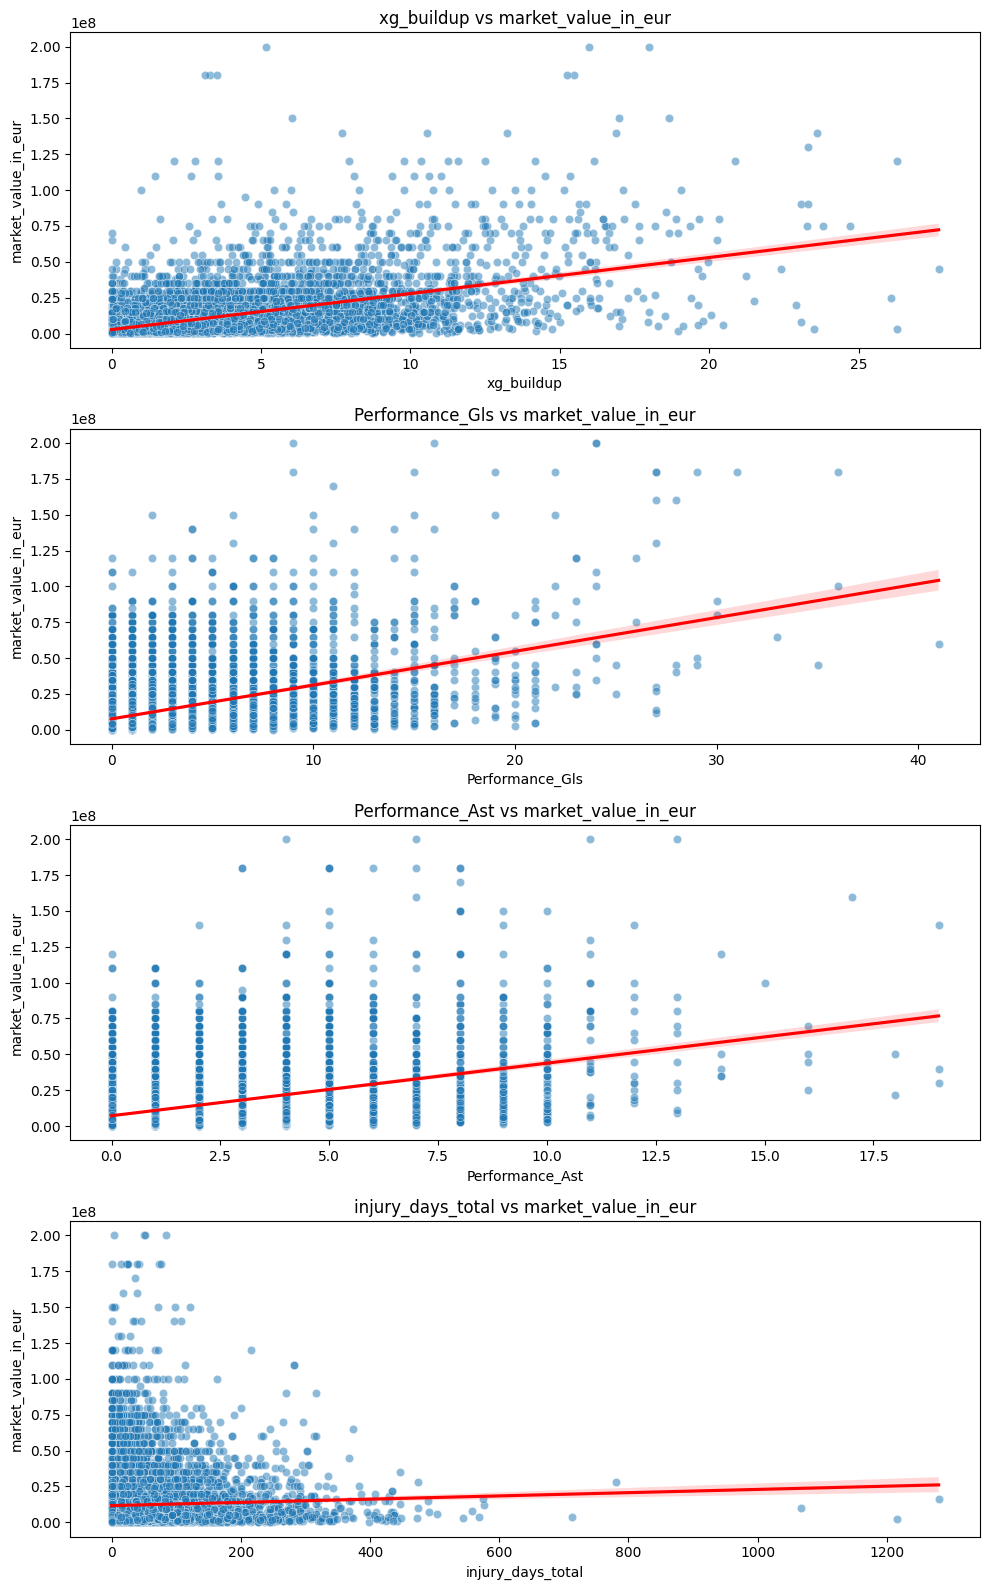

In [29]:
print("\nÉtudier les relations entre variables et VM")
if target in base.columns:
    corr_with_target = numeric_data.corr()[target].drop(labels=target).sort_values(ascending=False)
    display(corr_with_target)

    relation_columns = [c for c in ["age_numeric", "xg_buildup", "Performance_Gls", "Performance_Ast", "injury_days_total"] if c in base.columns]
    if relation_columns:
        fig, axs = plt.subplots(len(relation_columns), 1, figsize=(10, 4 * len(relation_columns)))
        if len(relation_columns) == 1:
            axs = [axs]
        for ax, col in zip(axs, relation_columns):
            sns.scatterplot(x=col, y=target, data=base, ax=ax, alpha=0.5)
            sns.regplot(x=col, y=target, data=base, ax=ax, scatter=False, line_kws={"color": "red"})
            ax.set_title(f"{col} vs {target}")
        plt.tight_layout()
    else:
        print("Aucune variable de relation sélectionnée disponible pour l'analyse.")
else:
    print(f"Impossible d'analyser les relations sans {target}")


Matrice de corrélation


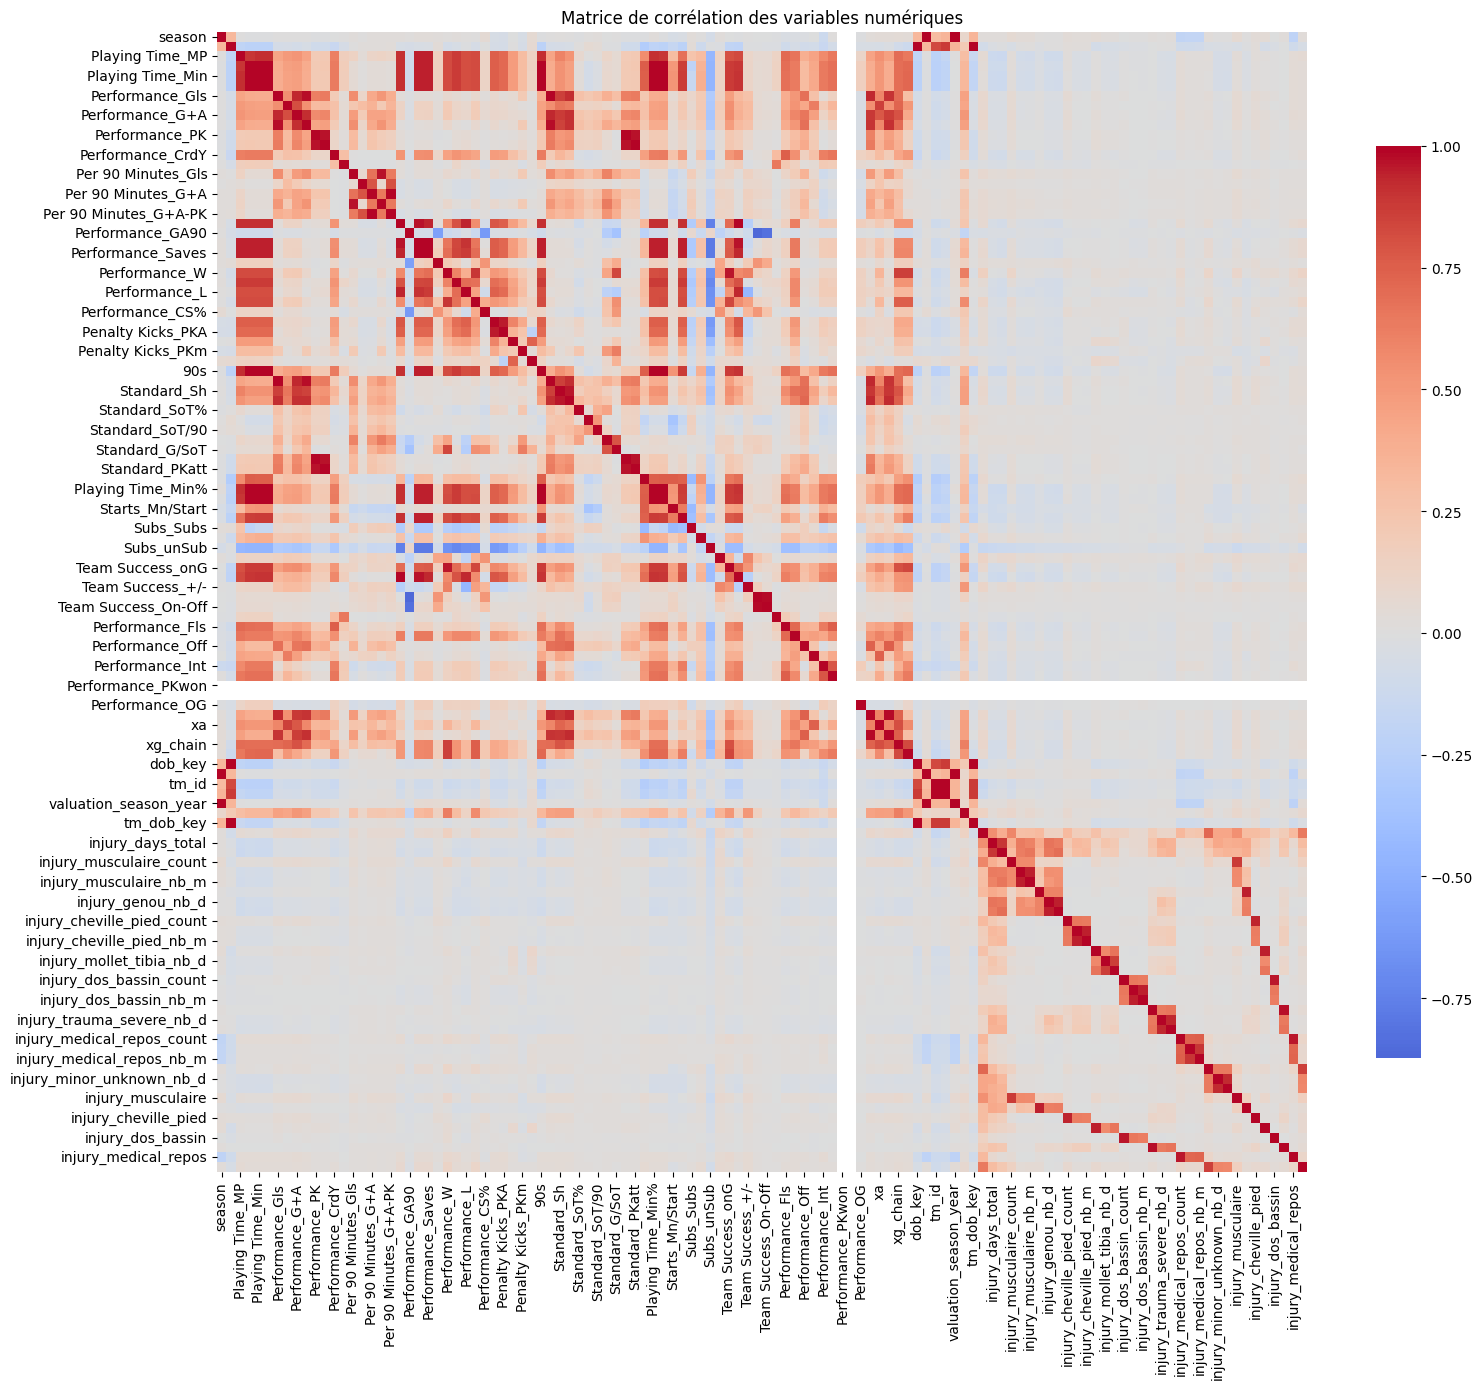

In [30]:
print("\nMatrice de corrélation")
if numeric_data.shape[1] > 1:
    corr_matrix = numeric_data.corr()
    plt.figure(figsize=(16, 14))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, fmt=".2f", square=False, cbar_kws={"shrink": 0.8})
    plt.title("Matrice de corrélation des variables numériques")
    plt.tight_layout()
else:
    print("Pas assez de variables numériques pour construire une matrice de corrélation.")